# 2D Ring Empirical experiment from Zhai Dobson Li paper

In this example this is the SDE:

$ dX_t = \left(-4X_t\left(\left\|X_t\right\|^2-1\right)+RX_t\right)dt + \sigma dW_t $

where $R$ is an antisymmetric matrix and $\sigma$ is a constant. In particular $\sigma\in\mathbb{R}$ (or $\sigma \parallel \text{Id}$)

The associated Fokker Planck equation is:

$ u_t = - \sum_i (f_i u)_{x_i} + \frac12\sum_{ij} (\Sigma_{ij}u)_{x_ix_j}$

where $f(x,t)=-4x\left(\left\|x\right\|^2-1\right)+Rx$ and $\Sigma(x,t)=\sigma(x,t)^T\sigma(x,t)$

In the article the author says that the theoretical steady state is:

$u(x) = \frac{1}{K}e^{\alpha V(\left\|x\right\|^2)}$

## Training

We want a neural network with parameters $\theta$ representd by $x\mapsto\tilde{u}(x,\theta)$ such that minimizes:

$$L(\theta) = \frac{1}{N^X}\sum_{i=1}^{N^X}(\mathcal{L}\tilde{u}(x_i,\theta))^2+\frac{1}{N^Y}\sum_{j=1}^{N^Y}(\tilde{u}(y_j,\theta)-v(y_j))^2:=L_1(\theta)+L_2(\theta)$$

where:
- $\theta$ is the set of parameters of the NN
- $x_i\in\mathbb{R}^n$ with $i=1,2,\ldots,N^X$
- $y_j\in\mathbb{R}^n$ with $j=1,2,\dots,N^Y$
- $v(y_j)$ is the solution of the MC approximation.

## Monte Carlo

Here we implement the function $v$, in the paper the authors report the procedure:

- A single trajectory for Euler-Maruyama numerical scheme with:
    - $10^7$ steps
    - the time step size is 0.001
    - empirical probability on a $200\times200$ mesh of the region $D = [−2,2] ×[−2,2]$
    - sampling from this trajectory 

In [20]:
# monte carlo implementation

import numpy as np
from zhai2022.sde import Model
from zhai2022.sde.euler_maruyama import EulerMaruyama

R = np.array([[0,1],[-1,0]])

# Define drift, diffusion, and initial state functions
def drift(X, t):
    return - 4 * (np.linalg.norm(X, axis=-1, keepdims=True)**2-1) * X + np.einsum('ij, sj -> si', R, X)

def diffusion(X, t):
    return np.tile(np.eye(X.shape[1]), (X.shape[0], 1, 1))

def initial_state(n_samples):
    return np.zeros((n_samples, 2))

# Create a Model instance
model = Model(drift, diffusion, initial_state, initial_time=0.0, n_dim=2)

# burn-in: 10sec of real time simulation
dt_schedule = np.ones(int(10/0.001)) * 0.001
euler_maruyama = EulerMaruyama(model, dt_schedule)
X = euler_maruyama.get_end(n_samples=1)  # shape: (1, 2)

# start simulation for 10^7 samples
dt_schedule = np.ones(10**7) * 0.001
def new_init(n_samples):
    return np.ones((n_samples, 2)) * X
model = Model(drift, diffusion, new_init, initial_time=0.0, n_dim=2)
euler_maruyama = EulerMaruyama(model, dt_schedule)
Xtrj = euler_maruyama.get_trajectory(n_samples=1)  # shape: (n_time_steps, 1, n_dim)


The idea is simple:

after a burn-in (in this case with 10sec of real time simulation and starting point in $0$), the authors make a single trajectory with many steps and a long time. Although there is a dependency between one sample and the next, the union of all samples from a long real time (10^4 seconds) trajectory allows us to no longer recognize the trajectory and have samples of the final distribution.

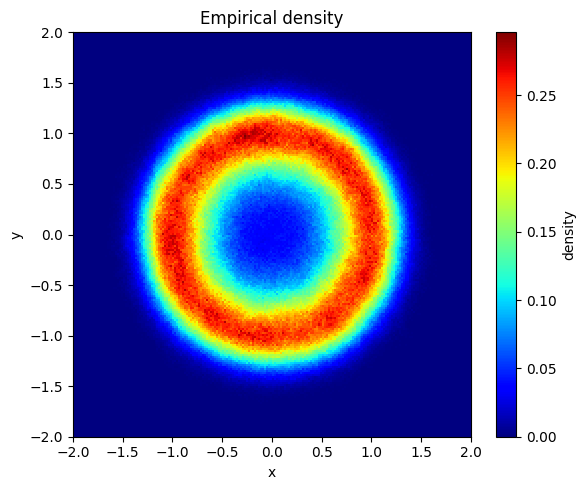

In [34]:
# see density
from matplotlib import pyplot as plt

# compute empirical density
x = Xtrj[:,0,0]
y = Xtrj[:,0,1]

# dominio e griglia
xmin, xmax = -2, 2
ymin, ymax = -2, 2
nx, ny = 200, 200   # come il paper

plt.figure(figsize=(6, 5))
counts, xedges, yedges, img = plt.hist2d(
    x, y,
    bins=[nx, ny],
    range=[[xmin, xmax], [ymin, ymax]],
    density=True,        # normalizza: somma ≈ 1
    cmap="jet",
    cmin=0,
)
plt.colorbar(label="density")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Empirical density")
plt.tight_layout()
plt.show()

In [55]:
def v(vec: np.ndarray):
    # vec has shape N,2
    mask = np.logical_and(
        np.logical_and(vec[:,0]>=xmin, vec[:,0]<xmax),
        np.logical_and(vec[:,1]>=ymin, vec[:,1]<ymax)
    )
    valid_vec = vec[mask]
    ix = np.searchsorted(xedges, valid_vec[:,0], side="right") - 1
    iy = np.searchsorted(yedges, valid_vec[:,1], side="right") - 1

    values = np.empty(vec.shape[0])

    values[mask] = counts[ix,iy]
    values[~mask] = 0.0

    return values

## Training

We want a neural network with parameters $\theta$ representd by $x\mapsto\tilde{u}(x,\theta)$ such that minimizes:

$$L(\theta) = \frac{1}{N^X}\sum_{i=1}^{N^X}(\mathcal{L}\tilde{u}(x_i,\theta))^2+\frac{1}{N^Y}\sum_{j=1}^{N^Y}(\tilde{u}(y_j,\theta)-v(y_j))^2:=L_1(\theta)+L_2(\theta)$$

where:
- $\theta$ is the set of parameters of the NN
- $x_i\in\mathbb{R}^n$ with $i=1,2,\ldots,N^X$
- $y_j\in\mathbb{R}^n$ with $j=1,2,\dots,N^Y$
- $v(y_j)$ is the solution of the MC approximation.

In this moment we have $v$, because we have the histogram of MC simulation.

###